In [18]:
import cv2
import numpy as np
import easyocr
import matplotlib.pyplot as plt

In [19]:
def show(img, title="image"):
    plt.figure(figsize=(5, 3))
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [20]:
def estimate_angle_from_crop(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return 0.0

    cnt = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(cnt)
    angle = rect[-1]

    # OpenCV correction
    if angle < -45:
        angle += 90

    return angle

In [21]:
def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

In [31]:
def preprocess_crop(crop, debug=False):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    angle = estimate_angle_from_crop(crop)
    rotated = rotate_image(thresh, angle)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    #cleaned = cv2.morphologyEx(rotated, cv2.MORPH_CLOSE, kernel)

    if debug:
        show(crop, "Original Crop")
        show(gray, "Grayscale")
        show(thresh, "Threshold")
        show(rotated, f"Deskewed (angle={angle:.2f})")
        #show(cleaned, "Final Image Sent to OCR")

    return rotated, angle

In [28]:
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


In [29]:
def read_number_from_crop(crop, debug=False):
    if crop is None:
        raise ValueError("Image not loaded. Check file path.")

    processed, angle = preprocess_crop(crop, debug=debug)

    results = reader.readtext(
        processed,
        allowlist="0123456789",
        detail=0,
        paragraph=False
    )

    number = results[0] if results else None
    return number, angle

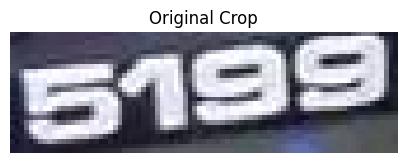

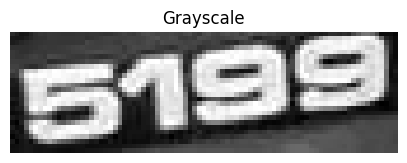

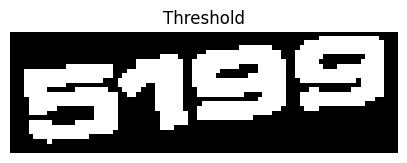

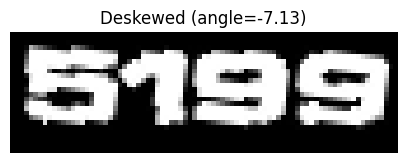

Detected number: 5199
Estimated angle: -7.125016212463379


c:\Users\traem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [33]:
# Load your PRE-CROPPED image
crop = cv2.imread("test_img.jpg")

number, angle = read_number_from_crop(crop, debug=True)

print("Detected number:", number)
print("Estimated angle:", angle)